# P1 — Data Spine

This notebook is the first platform verification notebook (Phase 6, NB-01).
Its purpose is periodic verification & validation: is the raw monthly data
still behaving as it did historically, and does every series' coverage look
the way an operator expects before anything is built on top of it? It is not
in the weekly scoring path — it is opened when something needs checking, not
on every run.

**Run `python scripts/build_platform_data.py` first if the `monthly_raw`
checkpoint is missing.**


In [1]:
%matplotlib inline
import logging

logging.basicConfig(level=logging.INFO)

from trading_crab_lib.platform.config import load_platform_config
from trading_crab_lib.platform import plotting as pplot
from trading_crab_lib.platform.plotting import data as pdata

cfg = load_platform_config()


In [2]:
monthly_raw = pplot.load_platform_checkpoint(
    "monthly_raw", rebuild_hint="python scripts/build_platform_data.py"
)
print("monthly_raw shape:", monthly_raw.shape)
print("monthly_raw index bounds:", monthly_raw.index.min(), "->", monthly_raw.index.max())


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: monthly_raw  (776 rows × 45 cols)


monthly_raw shape: (776, 45)
monthly_raw index bounds: 1962-01-31 00:00:00 -> 2026-08-31 00:00:00


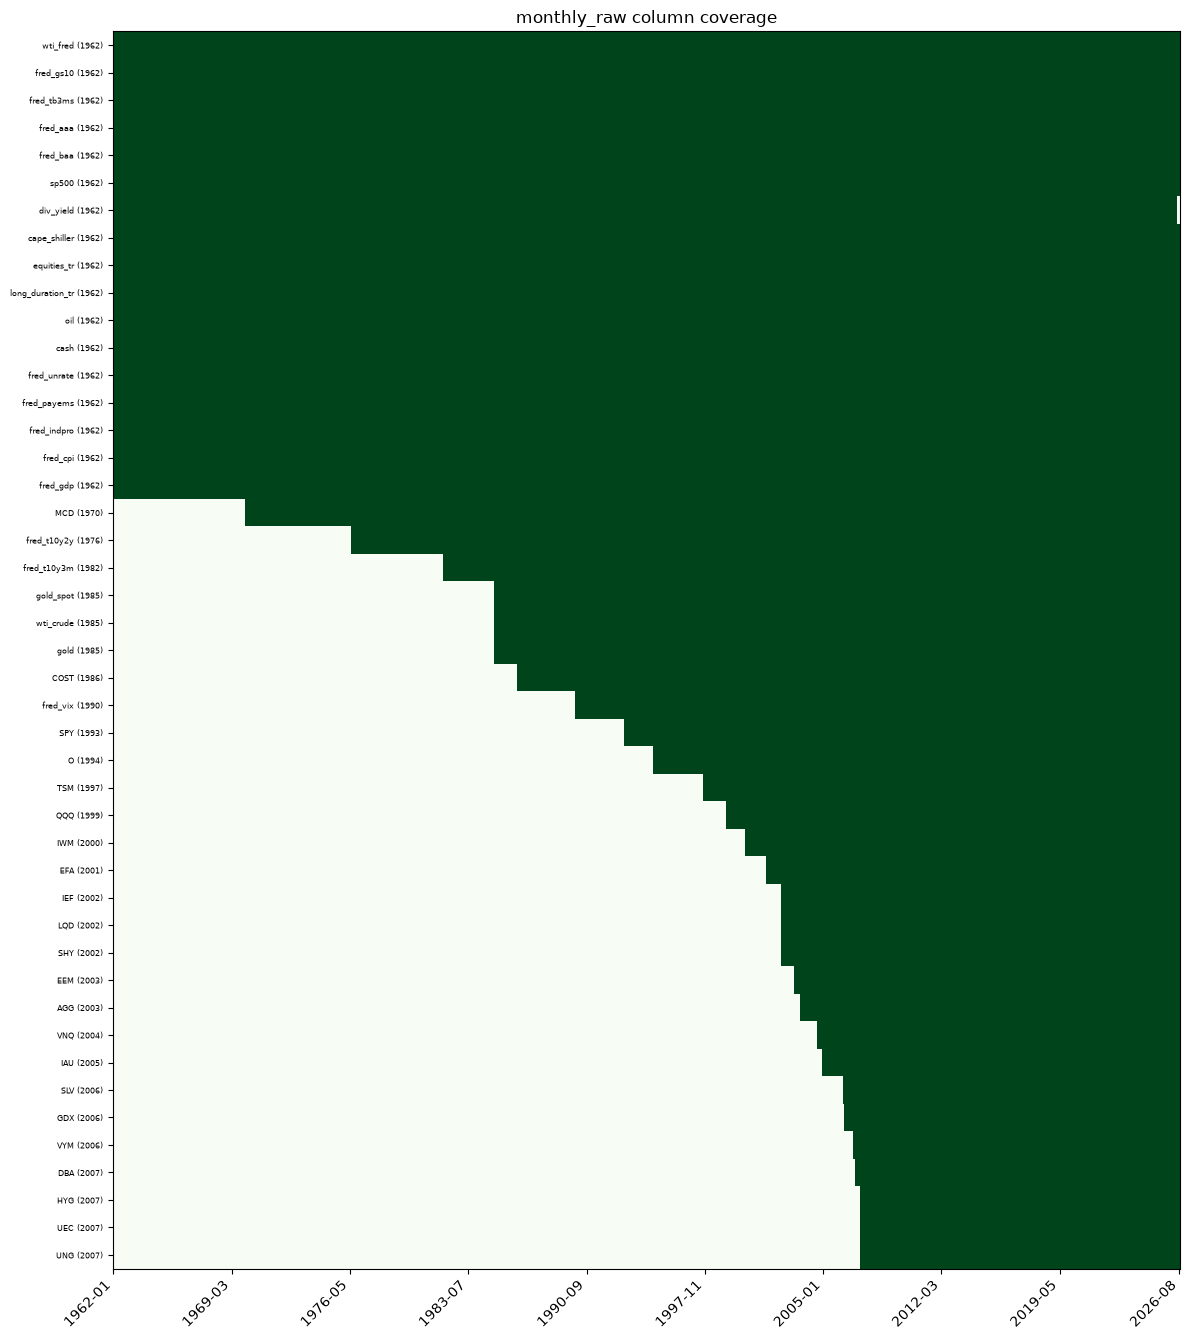

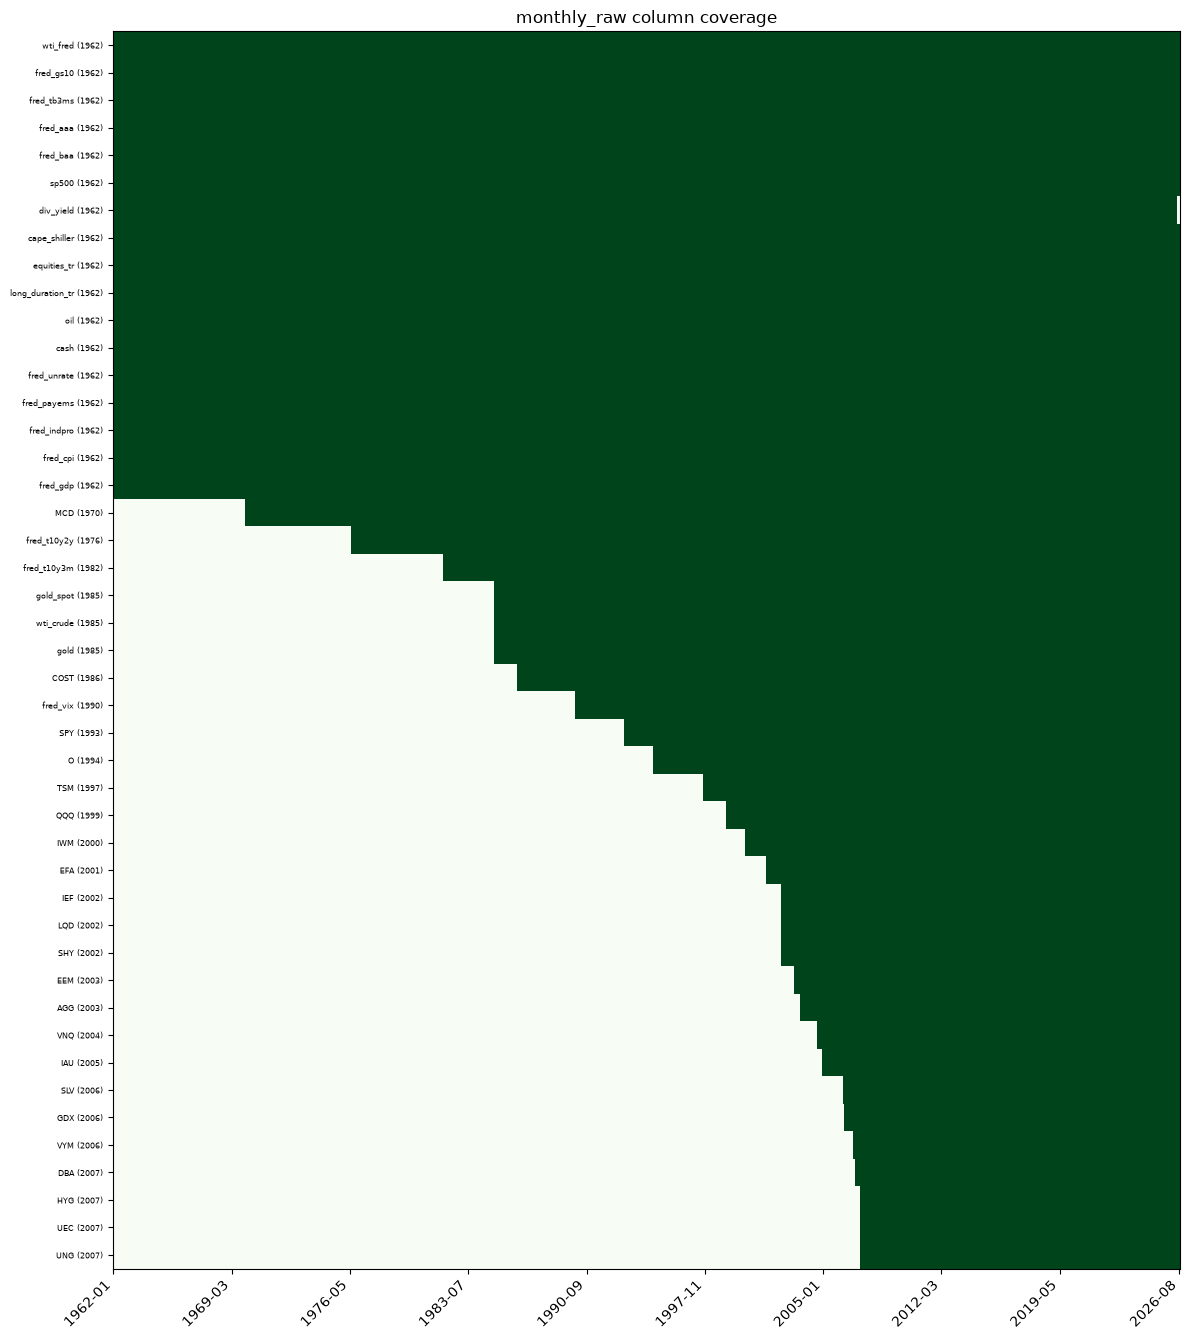

In [3]:
pdata.plot_coverage_timeline(monthly_raw, title="monthly_raw column coverage")


## What to look for

For every series (row) in the grid above: when does its first-valid date
land, and does it match what you would expect from that data source's known
history? More importantly — does any series stop updating (a solid green
band that ends well before the frame's last date on the right edge)? A
series that silently stopped updating will still look "available" in a
row/column count check; it only shows up here, visually, as a row that goes
dark before the right edge.
